# PROCESO_XAI — XAI Evaluation: Fidelity, Stability and Geographic Consistency (Colab)

> **Instructions to run:**
> 1. Run the **COLAB SETUP** cell below first
> 2. Adjust the `DRIVE_PARQUET` variable with the real path in your Google Drive
> 3. Run the cells in order with **Shift+Enter**
> 4. **Don't use Run All** — the long experiments need to run one at a time

**Total estimated time:** see the table in the notebook's introduction cell.

In [ ]:
# ── COLAB SETUP ─────────────────────────────────────────────────────────
# Step 1: mount Google Drive
from google.colab import drive
import os
# If already mounted, this line detects it automatically
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# Step 2: install libraries not included in Colab
!pip install imbalanced-learn lime -q

# Step 3: copy the parquet file from Drive to the local Colab environment
# ─── ADJUST this path to the folder where you uploaded the parquet in your Drive ───
DRIVE_PARQUET = '/content/drive/MyDrive/fci-datos/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet'
LOCAL_PARQUET = '/content/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet'
# ────────────────────────────────────────────────────────────────────────────

if not os.path.exists(LOCAL_PARQUET):
    import shutil
    shutil.copy(DRIVE_PARQUET, LOCAL_PARQUET)
    print(f'Parquet copied to {LOCAL_PARQUET}')
else:
    print(f'Parquet already available at {LOCAL_PARQUET}')

print('Setup complete.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Parquet copiado a /content/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet
Setup completado.


# XAI EVALUATION — Fidelity, Stability and Geographic Consistency

This notebook implements **Option B** for quantitative LIME evaluation:

| Evaluation | What it measures | Metric |
|---|---|---|
| Fidelity | How well LIME approximates the model locally | R² (LIME's internal score) |
| Stability | Variance of importances across runs | std over 10 seeds |
| Geographic consistency | Whether similar countries have similar explanations | Cosine similarity |

---
**Estimated time (Ryzen 7 5700G):** ~25 minutes total  
**Prerequisite:** having run `PROCESO_MODELADO_CV_v2.ipynb` first (the models are retrained here)

## Step 1 — Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
from imblearn.over_sampling import RandomOverSampler
from lime.lime_tabular import LimeTabularExplainer

print('Libraries loaded.')

Librerías cargadas.


## Step 2 — Load and preprocess

> **Adjust the path** if needed.

In [ ]:
# ─── ADJUST THIS PATH ────────────────────────────────────────────────────
PARQUET = 'part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet'
# ─────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(PARQUET)
for col in df.select_dtypes(include='string').columns:
    df[col] = df[col].astype(object)
df['DURATION']   = df['DURATION'].astype(float)
df['VALUE_EURO'] = pd.to_numeric(df['VALUE_EURO'], errors='coerce').astype(float)
for col in ['NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS','NUMBER_TENDERS_SME']:
    df[col] = df[col].astype(int)
df['GROUP_CPV'] = df['CPV'].astype(str).str[:2]
df['SME_WIN']   = df['B_CONTRACTOR_SME'].astype(str)\
                    .str.contains('y', case=False, na=False).astype(int)

cat_cols = ['B_MULTIPLE_CAE','B_ON_BEHALF','CAE_TYPE','MAIN_ACTIVITY',
            'ISO_COUNTRY_CODE','TYPE_OF_CONTRACT','GROUP_CPV']
for col in cat_cols: df[col] = df[col].astype(str)
ohe     = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_arr = ohe.fit_transform(df[cat_cols])
ohe_cols= ohe.get_feature_names_out(cat_cols)

num_cols= ['NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS','NUMBER_TENDERS_SME']
df_proc = pd.concat([
    df[num_cols+['MAIN_ACTIVITY','SME_WIN','ISO_COUNTRY_CODE']].reset_index(drop=True),
    pd.DataFrame(ohe_arr, columns=ohe_cols)
], axis=1)

print(f'Dataset: {df_proc.shape[0]:,} rows × {df_proc.shape[1]} columns')
print(f'SME_WIN: 1={df_proc["SME_WIN"].sum():,} ({df_proc["SME_WIN"].mean()*100:.1f}%) | '
      f'0={(df_proc["SME_WIN"]==0).sum():,}')

Dataset: 159,752 filas × 119 columnas
SME_WIN: 1=130,692 (81.8%) | 0=29,060


## Step 3 — Features and RF training (fold 10)

In [ ]:
uf_A = [c for c in [
    'B_MULTIPLE_CAE_n','B_ON_BEHALF_n','GROUP_CPV_45','GROUP_CPV_33','GROUP_CPV_15',
    'TYPE_OF_CONTRACT_w','ISO_COUNTRY_CODE_si',
    'NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS','NUMBER_TENDERS_SME',
    'CAE_TYPE_3',
    'CAE_TYPE_4','CAE_TYPE_5','ISO_COUNTRY_CODE_lu'] if c in df_proc.columns]

uf_B2 = [c for c in [
    'B_MULTIPLE_CAE_n','B_ON_BEHALF_n','GROUP_CPV_45','GROUP_CPV_33','GROUP_CPV_15',
    'TYPE_OF_CONTRACT_w','MAIN_ACTIVITY_health','ISO_COUNTRY_CODE_si',
    'NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS',
    'CAE_TYPE_3','MAIN_ACTIVITY_general public\\services',
    'CAE_TYPE_4','CAE_TYPE_5','ISO_COUNTRY_CODE_lu'] if c in df_proc.columns]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ros = RandomOverSampler(random_state=42)
X_A  = df_proc[uf_A].astype(float).to_numpy()
y_A  = np.array(df_proc['MAIN_ACTIVITY'].astype(str).tolist())
X_B2 = df_proc[uf_B2].astype(float).to_numpy()
y_B2 = df_proc['SME_WIN'].to_numpy()
iso  = df_proc['ISO_COUNTRY_CODE'].to_numpy()

for exp_name, X, y in [('A',X_A,y_A),('B2',X_B2,y_B2)]:
    tr_idx, te_idx = list(skf.split(X,y))[9]  # fold 10
    X_tr_b, y_tr_b = ros.fit_resample(X[tr_idx], y[tr_idx])
    t0 = time.time()
    rf = RandomForestClassifier(n_jobs=-1, max_samples=2/3,
                                 random_state=42, n_estimators=100,
                                 criterion='gini', max_features='sqrt')
    rf.fit(X_tr_b, y_tr_b)
    print(f'RF-{exp_name}: {time.time()-t0:.1f}s')
    if exp_name=='A':
        rf_A=rf; X_te_A=X[te_idx]; y_te_A=y[te_idx]
    else:
        rf_B2=rf; X_te_B2=X[te_idx]; y_te_B2=y[te_idx]; iso_te=iso[te_idx]

RF-A: 84.0s
RF-B2: 16.8s


## Step 4 — Helper function for LIME importances

In [ ]:
def lime_importance_vector(exp, label, feature_names):
    """
    Extracts the LIME importance vector indexed by feature_names.
    LIME returns conditions like 'NUMBER_AWARDS > 20.00' — this function
    maps each condition to its corresponding feature name.
    """
    vec  = np.zeros(len(feature_names))
    f2i  = {f:i for i,f in enumerate(feature_names)}
    for cond, val in exp.as_list(label=label):
        # Find which feature appears in the condition
        for f in sorted(feature_names, key=len, reverse=True):
            if f in cond:
                vec[f2i[f]] = val
                break
    return vec

# Create explainers
explainer_A = LimeTabularExplainer(
    X_te_A, feature_names=uf_A,
    class_names=list(np.unique(y_te_A)),
    mode='classification', random_state=42)

explainer_B2 = LimeTabularExplainer(
    X_te_B2, feature_names=uf_B2,
    class_names=['No-SME','SME-WIN'],
    mode='classification', random_state=42)

print('Explainers created.')

Explainers creados.


## Step 4b — Train Gradient Boosting for Exp. A (coherent with the definitive CV pipeline)

`rf_A` (Step 3) was trained on the balanced fold-10 training set for Exp. A, but Gradient Boosting was never trained for Exp. A in this notebook.
To keep Figures 11 and 12 fully coherent with the rest of the paper, we recompute the **exact same** fold-10 balanced
training set (deterministic given `random_state=42`) and train `gb_A` with the **same hyperparameters** used in the
definitive CV pipeline (`PROCESO_MODELADO_CV_v2`, Step 6).

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# ── Recompute Exp. A's fold-10 balanced training set (identical to what rf_A trained on) ──
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
ros = RandomOverSampler(random_state=42)
tr_idx_A, te_idx_A = list(skf.split(X_A, y_A))[9]     # fold 10, same as rf_A
X_tr_b_A, y_tr_b_A = ros.fit_resample(X_A[tr_idx_A], y_A[tr_idx_A])

# ── Train Gradient Boosting with the EXACT hyperparameters used in the definitive CV pipeline ──
gb_A = GradientBoostingClassifier(
    max_features  = 'sqrt',
    learning_rate = 0.1,
    n_estimators  = 100,
    random_state  = 42
)
gb_A.fit(X_tr_b_A, y_tr_b_A)
print('GB-A trained with the same hyperparameters and fold-10 split as reported in the paper.')

GB-A trained with the same hyperparameters and fold-10 split as reported in the paper.


## Step 4c — Generate Figures 11 and 12 (LIME_RF.png / LIME_GB.png, English)

Selects a representative test instance from Exp. A, generates LIME explanations for both models on the **same**
instance, prints the corresponding if-then rule in English, and saves each plot as a standalone PNG.

Selected instance index: 4 | RF-predicted class: general public\services
Rules for class general public\services (Random Forest):
  Under the current conditions, contracting is recommended for general public\services. The following features are influential: CAE_TYPE_3 > 0.00 has an importance of 0.4689, CAE_TYPE_4 <= 0.00 has an importance of 0.1176, GROUP_CPV_33 <= 0.00 has an importance of 0.1145, GROUP_CPV_45 > 0.00 has an importance of 0.1030, TYPE_OF_CONTRACT_w > 0.00 has an importance of 0.0913.


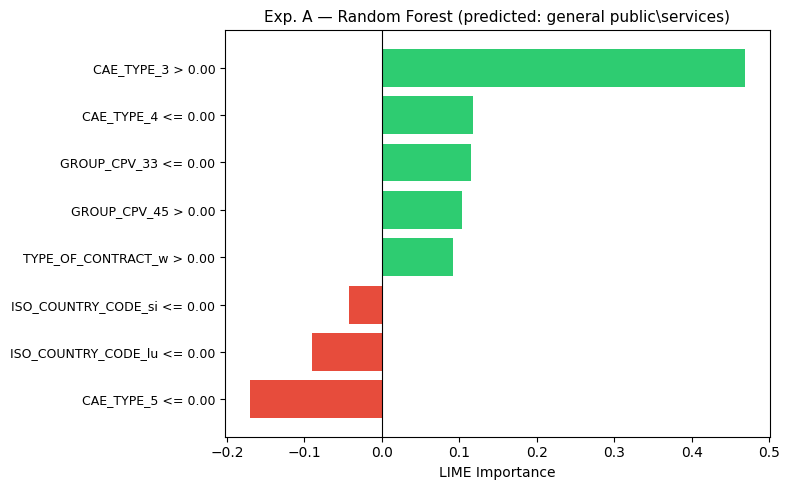

Saved as LIME_RF.png
Rules for class general public\services (Gradient Boosting):
  Under the current conditions, contracting is recommended for general public\services. The following features are influential: CAE_TYPE_3 > 0.00 has an importance of 0.3680, CAE_TYPE_4 <= 0.00 has an importance of 0.0970, TYPE_OF_CONTRACT_w > 0.00 has an importance of 0.0608, GROUP_CPV_45 > 0.00 has an importance of 0.0468, GROUP_CPV_33 <= 0.00 has an importance of 0.0391.


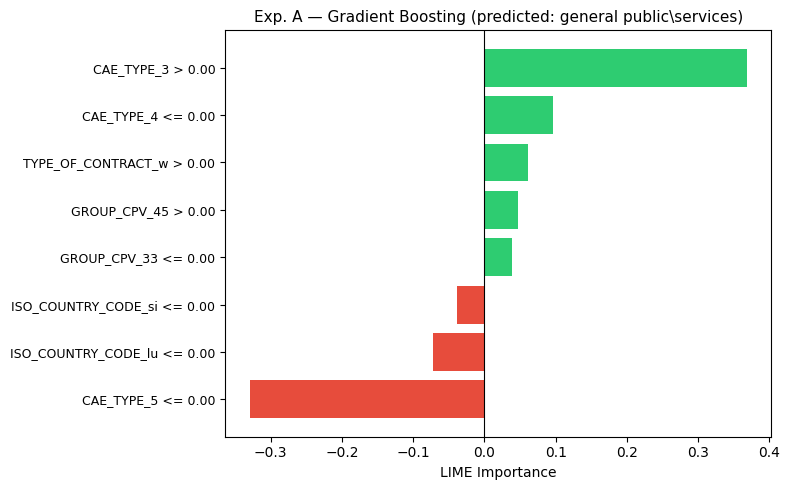

Saved as LIME_GB.png

>>> IMPORTANT: compare the top features shown above against the current LaTeX captions for
    Fig. 11 (fig: XAI_RF_GA) and Fig. 12 (fig: XAI_GB_GA) and rewrite them to match the actual output.


In [ ]:
def convert_to_if_then(explanation, class_name, instance_to_explain):
    """English version of the original if-then rule generator (see PROCESO_MODELADO.ipynb)."""
    rule_parts = []
    try:
        for feature_name, importance in explanation.as_list(label=class_name):
            if importance > 0:
                rule_parts.append(f"{feature_name} has an importance of {importance:.4f}")
        if rule_parts:
            combined_rule = (f"Under the current conditions, contracting is recommended for {instance_to_explain}. "
                              "The following features are influential: " + ", ".join(rule_parts) + ".")
        else:
            combined_rule = (f"Under the current conditions, contracting is recommended for {instance_to_explain}. "
                              "No features with positive importance were found.")
    except KeyError:
        combined_rule = (f"Under the current conditions, contracting is recommended for {instance_to_explain}. "
                          "No explanations were found for this class.")
    return [combined_rule]


def generate_explanatory_plot(model, model_label, instance, feature_names, class_names, predicted_class, save_path):
    explainer = LimeTabularExplainer(
        training_data=X_te_A, feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=42)
    exp = explainer.explain_instance(instance, model.predict_proba, num_features=8, top_labels=1)
    label = exp.available_labels()[0]
    class_name_str = class_names[label] if isinstance(class_names, (list, np.ndarray)) else label

    print(f'Rules for class {class_name_str} ({model_label}):')
    for rule in convert_to_if_then(exp, label, predicted_class):
        print(f'  {rule}')

    feats_vals = sorted(exp.as_list(label=label), key=lambda x: x[1])
    feats, vals = zip(*feats_vals)
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in vals]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(feats)), vals, color=colors)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Importance')
    ax.set_title(f'Exp. A — {model_label} (predicted: {class_name_str})', fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved as {save_path}')
    return exp, label


# ── Pick one representative test instance (same instance for RF and GB) ──
class_names_A = sorted(np.unique(y_te_A))
pred_rf_all   = rf_A.predict(X_te_A)
target_class  = 'general public\\services'   # adjust if this exact label does not exist in class_names_A
idx_candidates = np.where(pred_rf_all == target_class)[0]
if len(idx_candidates) == 0:
    # Fallback: use the most frequent predicted class if the target label is not present
    values, counts = np.unique(pred_rf_all, return_counts=True)
    target_class = values[np.argmax(counts)]
    idx_candidates = np.where(pred_rf_all == target_class)[0]
    print(f'Target class not found — falling back to most frequent predicted class: {target_class}')
idx_inst = int(idx_candidates[0])
print(f'Selected instance index: {idx_inst} | RF-predicted class: {pred_rf_all[idx_inst]}')

# ── Figure 11: Random Forest ──
exp_rf, label_rf = generate_explanatory_plot(
    rf_A, 'Random Forest', X_te_A[idx_inst], uf_A, class_names_A, pred_rf_all[idx_inst], 'LIME_RF.png')

# ── Figure 12: Gradient Boosting (SAME instance) ──
pred_gb_all = gb_A.predict(X_te_A)
exp_gb, label_gb = generate_explanatory_plot(
    gb_A, 'Gradient Boosting', X_te_A[idx_inst], uf_A, class_names_A, pred_gb_all[idx_inst], 'LIME_GB.png')

print('\n>>> IMPORTANT: compare the top features shown above against the current LaTeX captions for')
print('    Fig. 11 (fig: XAI_RF_GA) and Fig. 12 (fig: XAI_GB_GA) and rewrite them to match the actual output.')

## Step 5 — Representative instances for Exp B2

One instance with high confidence for SME_WIN=1 and another with high confidence for SME_WIN=0.

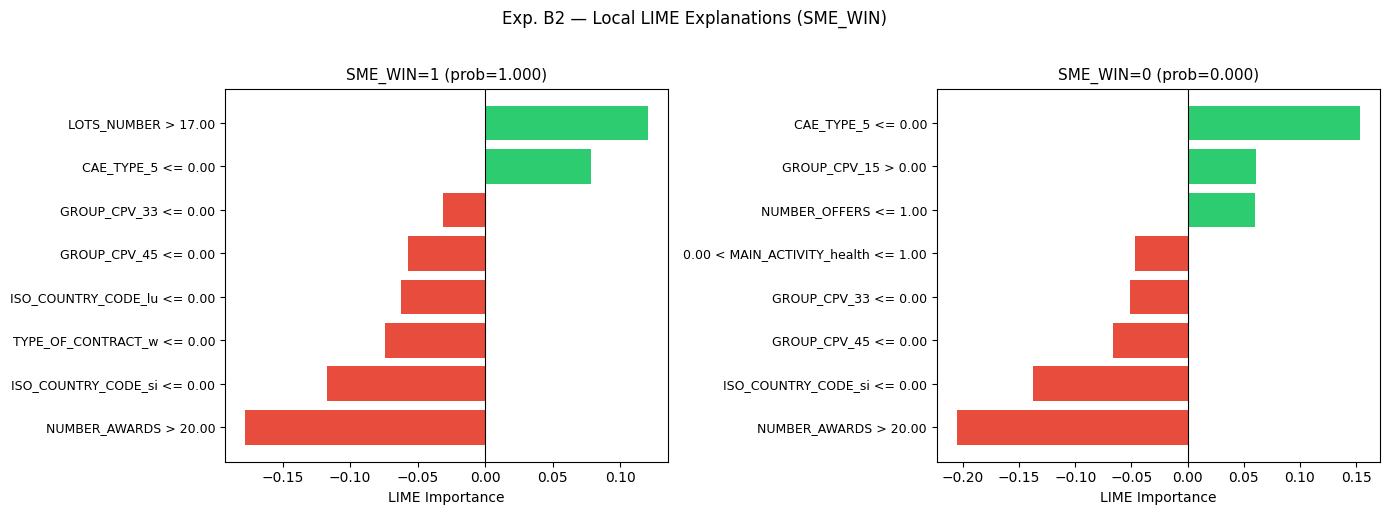

Guardada como LIME_B2_instancias.png


In [ ]:
probs   = rf_B2.predict_proba(X_te_B2)[:,1]
idx_pos = int(np.where(y_te_B2==1)[0][np.argmax(probs[y_te_B2==1])])
idx_neg = int(np.where(y_te_B2==0)[0][np.argmax(1-probs[y_te_B2==0])])

exp_pos = explainer_B2.explain_instance(
    X_te_B2[idx_pos], rf_B2.predict_proba, num_features=8, num_samples=1000)
exp_neg = explainer_B2.explain_instance(
    X_te_B2[idx_neg], rf_B2.predict_proba, num_features=8, num_samples=1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, exp, titulo, prob in [
    (axes[0], exp_pos, f'SME_WIN=1 (prob={probs[idx_pos]:.3f})', probs[idx_pos]),
    (axes[1], exp_neg, f'SME_WIN=0 (prob={probs[idx_neg]:.3f})', probs[idx_neg])
]:
    features_vals = sorted(exp.as_list(label=1), key=lambda x: x[1])
    features, vals = zip(*features_vals)
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in vals]
    ax.barh(range(len(features)), vals, color=colors)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels([f[:40] for f in features], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('LIME Importance')
plt.suptitle('Exp. B2 — Local LIME Explanations (SME_WIN)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('LIME_B2_instancias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as LIME_B2_instancias.png')

## Step 6 — Evaluation 1: Local Fidelity (R²)

**~10 minutes**. Measures how well LIME (a local linear model) approximates RF in the neighborhood of each instance.

Calculando fidelidad Exp B2 (50 instancias)...
  10/50
  20/50
  30/50
  40/50
  50/50
Calculando fidelidad Exp A (20 instancias)...
  5/20
  10/20
  15/20
  20/20

Fidelidad Exp A:  R²=0.4313 ± 0.2906 | >0.85: 0.0%
Fidelidad Exp B2: R²=0.1619 ± 0.0738 | >0.85: 0.0%


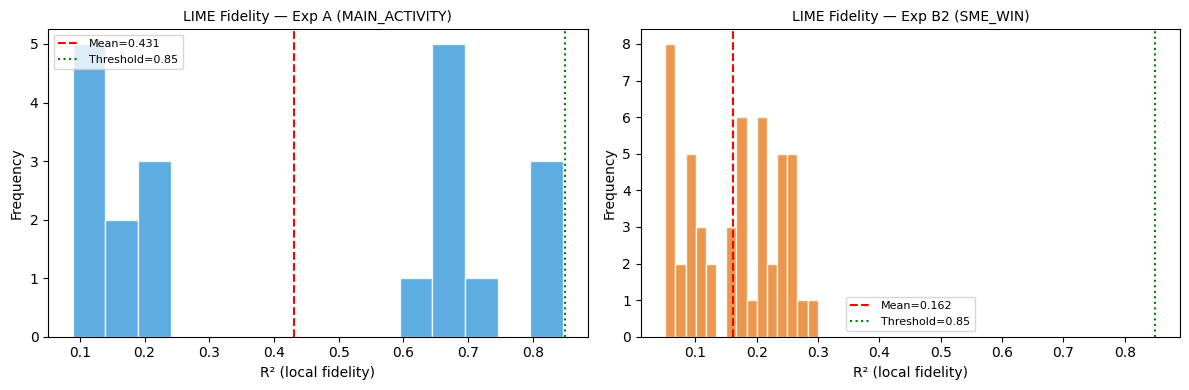

Guardada como LIME_fidelidad.png


In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_te_B2), 50, replace=False)
r2_B2, r2_A = [], []

print('Computing fidelity for Exp B2 (50 instances)...')
for i, idx in enumerate(sample_idx):
    e = explainer_B2.explain_instance(
        X_te_B2[idx], rf_B2.predict_proba,
        num_features=len(uf_B2), num_samples=500, labels=(1,))
    r2_B2.append(float(e.score))
    if (i+1) % 10 == 0: print(f'  {i+1}/50')

print('Computing fidelity for Exp A (20 instances)...')
for i, idx in enumerate(sample_idx[:20]):
    e = explainer_A.explain_instance(
        X_te_A[idx], rf_A.predict_proba,
        num_features=len(uf_A), num_samples=500, top_labels=1)
    r2_A.append(float(e.score))
    if (i+1) % 5 == 0: print(f'  {i+1}/20')

print(f'\nFidelity Exp A:  R²={np.mean(r2_A):.4f} ± {np.std(r2_A):.4f} | >0.85: {np.mean(np.array(r2_A)>0.85)*100:.1f}%')
print(f'Fidelity Exp B2: R²={np.mean(r2_B2):.4f} ± {np.std(r2_B2):.4f} | >0.85: {np.mean(np.array(r2_B2)>0.85)*100:.1f}%')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r2, label, color in [
    (axes[0], r2_A,  'Exp A (MAIN_ACTIVITY)', '#3498db'),
    (axes[1], r2_B2, 'Exp B2 (SME_WIN)',      '#e67e22')
]:
    ax.hist(r2, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(r2), color='red', linestyle='--', label=f'Mean={np.mean(r2):.3f}')
    ax.axvline(0.85, color='green', linestyle=':', label='Threshold=0.85')
    ax.set_title(f'LIME Fidelity — {label}', fontsize=10)
    ax.set_xlabel('R² (local fidelity)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('LIME_fidelidad.png', dpi=150)
plt.show()
print('Saved as LIME_fidelidad.png')

## Step 7 — Evaluation 2: Stability

**~5 minutes**. Measures whether the importances are reproducible across different random seeds.

In [ ]:
stable_idx = sample_idx[:5]
stab_B2, stab_A = [], []

print('Computing stability for Exp B2...')
for idx in stable_idx:
    vecs = []
    for seed in range(10):
        ex = LimeTabularExplainer(X_te_B2, feature_names=uf_B2,
                                   class_names=['No-SME','SME-WIN'],
                                   mode='classification', random_state=seed)
        e  = ex.explain_instance(X_te_B2[idx], rf_B2.predict_proba,
                                  num_features=len(uf_B2), num_samples=500, labels=(1,))
        vecs.append(lime_importance_vector(e, 1, uf_B2))
    stab_B2.append(np.mean(np.std(np.array(vecs), axis=0)))

print('Computing stability for Exp A...')
for idx in stable_idx:
    vecs = []
    for seed in range(10):
        ex = LimeTabularExplainer(X_te_A, feature_names=uf_A,
                                   class_names=list(np.unique(y_te_A)),
                                   mode='classification', random_state=seed)
        e  = ex.explain_instance(X_te_A[idx], rf_A.predict_proba,
                                  num_features=len(uf_A), num_samples=500, top_labels=1)
        lbl = e.available_labels()[0]
        vecs.append(lime_importance_vector(e, lbl, uf_A))
    stab_A.append(np.mean(np.std(np.array(vecs), axis=0)))

print(f'\nStability Exp A:  std={np.mean(stab_A):.4f} ± {np.std(stab_A):.4f}')
print(f'Stability Exp B2: std={np.mean(stab_B2):.4f} ± {np.std(stab_B2):.4f}')
print(f'Interpretation: values close to 0 indicate high stability (reproducible importances).')

Calculando estabilidad Exp B2...
Calculando estabilidad Exp A...

Estabilidad Exp A:  std=0.0130 ± 0.0072
Estabilidad Exp B2: std=0.0239 ± 0.0009
Interpretación: valores cercanos a 0 indican alta estabilidad (importancias reproducibles).


## Step 8 — Evaluation 3: Geographic Consistency

**~10 minutes**. Checks whether countries with similar SME-award rates have similar LIME explanations.

  PL: n=6237  SME_rate=0.856
  DE: n=505  SME_rate=0.776
  FR: n=1807  SME_rate=0.792
  RO: n=2193  SME_rate=0.638
  BG: n=394  SME_rate=0.939
  CZ: n= 88  SME_rate=0.932
  LT: n= 99  SME_rate=0.939
  AT: n= 81  SME_rate=0.667


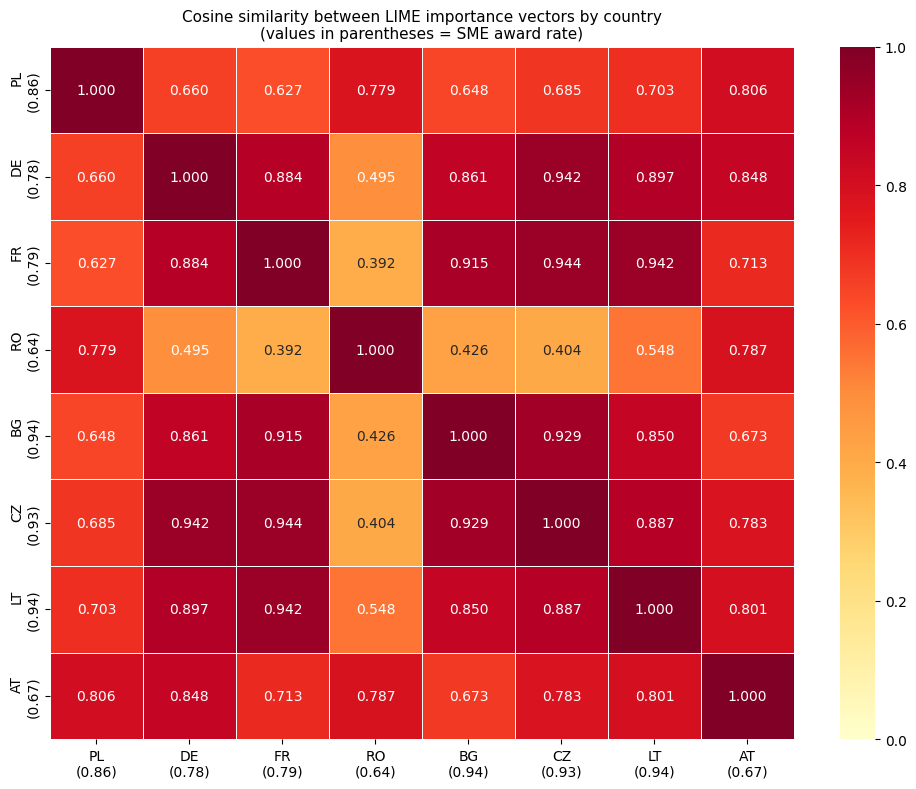

Guardada como LIME_consistencia_geografica.png


In [ ]:
top_countries = ['pl','de','fr','ro','bg','cz','lt','at']
country_vecs, country_rates = {}, {}

for country in top_countries:
    mask = np.array([str(x).lower()==country for x in iso_te])
    if mask.sum() < 3: continue
    idx_c = np.where(mask)[0][:8]
    vecs  = []
    for idx in idx_c:
        e = explainer_B2.explain_instance(
            X_te_B2[idx], rf_B2.predict_proba,
            num_features=len(uf_B2), num_samples=500, labels=(1,))
        vecs.append(lime_importance_vector(e, 1, uf_B2))
    country_vecs[country.upper()]  = np.mean(vecs, axis=0)
    country_rates[country.upper()] = float(y_te_B2[mask].mean())
    print(f'  {country.upper()}: n={mask.sum():3d}  SME_rate={y_te_B2[mask].mean():.3f}')

found = list(country_vecs.keys())
mat   = np.array([country_vecs[c] for c in found])
sim   = cosine_similarity(mat)

# Heatmap
labels_ext = [f'{c}\n({country_rates[c]:.2f})' for c in found]
plt.figure(figsize=(10, 8))
sns.heatmap(sim, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=labels_ext, yticklabels=labels_ext,
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Cosine similarity between LIME importance vectors by country\n'
          '(values in parentheses = SME award rate)', fontsize=11)
plt.tight_layout()
plt.savefig('LIME_consistencia_geografica.png', dpi=150)
plt.show()
print('Saved as LIME_consistencia_geografica.png')

## Step 9 — XAI Summary Table for the Paper

In [ ]:
print('='*65)
print('XAI SUMMARY TABLE')
print('='*65)
print(f'\nFidelity (LIME internal R²):')
print(f'  Exp A:  {np.mean(r2_A):.4f} ± {np.std(r2_A):.4f}  | >0.85: {np.mean(np.array(r2_A)>0.85)*100:.1f}%')
print(f'  Exp B2: {np.mean(r2_B2):.4f} ± {np.std(r2_B2):.4f}  | >0.85: {np.mean(np.array(r2_B2)>0.85)*100:.1f}%')
print(f'\nStability (std of importances, 10 seeds):')
print(f'  Exp A:  {np.mean(stab_A):.4f} ± {np.std(stab_A):.4f}')
print(f'  Exp B2: {np.mean(stab_B2):.4f} ± {np.std(stab_B2):.4f}')
print(f'\nGeographic consistency — key findings:')
# Top most similar and most different pairs
pares = []
for i,c1 in enumerate(found):
    for j,c2 in enumerate(found):
        if j>i:
            pares.append((sim[i,j], c1, c2,
                          abs(country_rates[c1]-country_rates[c2])))
pares.sort(reverse=True)
print('  Most similar pairs:')
for s,c1,c2,dr in pares[:3]:
    print(f'    {c1}({country_rates[c1]:.2f})–{c2}({country_rates[c2]:.2f}): sim={s:.4f} Δrate={dr:.2f}')
print('  Most different pairs:')
for s,c1,c2,dr in pares[-3:]:
    print(f'    {c1}({country_rates[c1]:.2f})–{c2}({country_rates[c2]:.2f}): sim={s:.4f} Δrate={dr:.2f}')

print('\n--- LaTeX CODE for XAI table ---')
print(r'\begin{table}[htb]')
print(r'\small\centering')
print(r'\caption{Quantitative evaluation of LIME: fidelity and stability.}')
print(r'\label{tab:xai_eval}')
print(r'\begin{tabular}{lcc}\hline')
print(r'\textbf{Evaluation} & \textbf{Exp.~A} & \textbf{Exp.~B2} \\ \hline')
print(f'Fidelity (R²) & '
      f'${np.mean(r2_A):.4f} \\pm {np.std(r2_A):.4f}$ & '
      f'${np.mean(r2_B2):.4f} \\pm {np.std(r2_B2):.4f}$ \\\\')
print(f'\\% instances R²$>$0.85 & '
      f'${np.mean(np.array(r2_A)>0.85)*100:.1f}$\\% & '
      f'${np.mean(np.array(r2_B2)>0.85)*100:.1f}$\\% \\\\')
print(f'Stability (std) & '
      f'${np.mean(stab_A):.4f} \\pm {np.std(stab_A):.4f}$ & '
      f'${np.mean(stab_B2):.4f} \\pm {np.std(stab_B2):.4f}$ \\\\')
print(r'\hline\end{tabular}\end{table}')

TABLA RESUMEN XAI

Fidelidad (R² interno de LIME):
  Exp A:  0.4313 ± 0.2906  | >0.85: 0.0%
  Exp B2: 0.1619 ± 0.0738  | >0.85: 0.0%

Estabilidad (std importancias, 10 semillas):
  Exp A:  0.0130 ± 0.0072
  Exp B2: 0.0239 ± 0.0009

Consistencia geográfica — hallazgos clave:
  Pares más similares:
    FR(0.79)–CZ(0.93): sim=0.9445 Δrate=0.14
    DE(0.78)–CZ(0.93): sim=0.9424 Δrate=0.16
    FR(0.79)–LT(0.94): sim=0.9416 Δrate=0.15
  Pares más distintos:
    RO(0.64)–BG(0.94): sim=0.4258 Δrate=0.30
    RO(0.64)–CZ(0.93): sim=0.4038 Δrate=0.29
    FR(0.79)–RO(0.64): sim=0.3922 Δrate=0.15

--- CÓDIGO LaTeX tabla XAI ---
\begin{table}[htb]
\small\centering
\caption{Evaluaci\'on cuantitativa de LIME: fidelidad y estabilidad.}
\label{tab:xai_eval}
\begin{tabular}{lcc}\hline
\textbf{Evaluaci\'on} & \textbf{Exp.~A} & \textbf{Exp.~B2} \\ \hline
Fidelidad (R²) & $0.4313 \pm 0.2906$ & $0.1619 \pm 0.0738$ \\
\% instancias R²$>$0.85 & $0.0$\% & $0.0$\% \\
Estabilidad (std) & $0.0130 \pm 0.0072$ & $0.